# Anfänger - CartPole-v1 environment exploration

This notebook solves the beginner tasks for Lerntag 13. The focus is understanding the Gymnasium environment, observations, actions, rewards and episode termination.

## Dataset Validation
Run this cell to verify that your datasets are present and correctly formatted.

In [ ]:
# --- DATASET VALIDATION ---
import os
import pandas as pd

def validate_dataset(filepath, expected_columns=None, avoid_columns=None):
    if not os.path.exists(filepath):
        print(f'❌ ERROR: Dataset not found at {filepath}')
        return False
    try:
        df = pd.read_csv(filepath, nrows=5)
        print(f'✅ SUCCESS: Dataset found at {filepath} (Columns: {df.shape[1]})')
        if expected_columns:
            missing = [c for c in expected_columns if c not in df.columns]
            if missing:
                print(f'⚠️ WARNING: Missing expected columns: {missing}')
                return False
        if avoid_columns:
            forbidden = [c for c in avoid_columns if c in df.columns]
            if forbidden:
                print(f'❌ ERROR: Found forbidden columns {forbidden}. Wrong dataset!')
                return False
        return True
    except Exception as e:
        print(f'❌ ERROR: Could not read dataset: {e}')
        return False

print('Validation helper loaded. Call validate_dataset(path) before loading your data.')
# validate_dataset('../data/your_dataset.csv')

In [1]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 13
np.random.seed(SEED)

In [2]:
env = gym.make("CartPole-v1")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Number of actions:", env.action_space.n)
env.close()

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Number of actions: 2


In [3]:
def run_random_policy(n_episodes=5, seed=SEED):
    env = gym.make("CartPole-v1")
    rewards = []
    for episode in range(n_episodes):
        state, info = env.reset(seed=seed + episode)
        done = False
        total_reward = 0
        while not done:
            action = env.action_space.sample()
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward
            state = next_state
        rewards.append(total_reward)
        print(f"Episode {episode + 1}: total reward = {total_reward:.0f}")
    env.close()
    return rewards

random_rewards_5 = run_random_policy(n_episodes=5)

Episode 1: total reward = 24
Episode 2: total reward = 21
Episode 3: total reward = 14
Episode 4: total reward = 18
Episode 5: total reward = 17


## Observation variables

CartPole returns four observation values:

| Variable | Meaning |
|---|---|
| Cart position | Position of the cart on the horizontal track |
| Cart velocity | Speed and direction of the cart |
| Pole angle | Angle of the pole relative to vertical position |
| Pole angular velocity | Speed and direction of pole rotation |

`done=True` means the episode is finished. In Gymnasium this is represented by `terminated=True` or `truncated=True`. The episode can end because the pole falls too far, the cart leaves the allowed range, or the maximum episode length is reached.

In [4]:
def heuristic_action(observation):
    cart_position, cart_velocity, pole_angle, pole_angular_velocity = observation
    return 1 if pole_angle > 0 else 0


def evaluate_policy(policy_fn, n_episodes=100, seed=SEED):
    env = gym.make("CartPole-v1")
    rewards = []
    for episode in range(n_episodes):
        state, info = env.reset(seed=seed + episode)
        done = False
        total_reward = 0
        while not done:
            action = policy_fn(env, state)
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward
        rewards.append(total_reward)
    env.close()
    return np.array(rewards)

random_policy = lambda env, state: env.action_space.sample()
angle_policy = lambda env, state: heuristic_action(state)

random_rewards = evaluate_policy(random_policy, n_episodes=100)
heuristic_rewards = evaluate_policy(angle_policy, n_episodes=100)

comparison = pd.DataFrame({
    "policy": ["Random policy", "Angle heuristic"],
    "mean_total_reward": [random_rewards.mean(), heuristic_rewards.mean()],
    "std_total_reward": [random_rewards.std(), heuristic_rewards.std()]
})
comparison

,policy,mean_total_reward,std_total_reward
0,Random policy,21.33,11.169651
1,Angle heuristic,41.29,8.878395


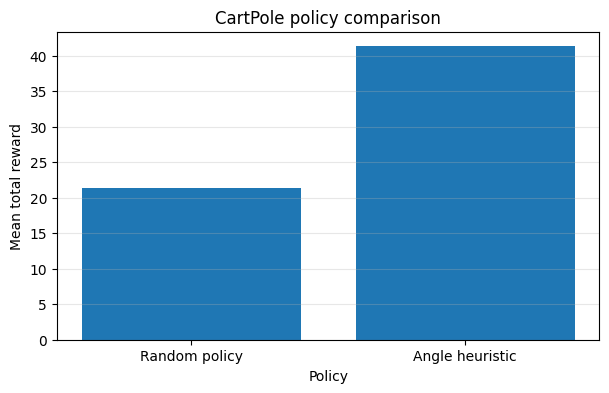

In [5]:
plt.figure(figsize=(7, 4))
plt.bar(comparison["policy"], comparison["mean_total_reward"])
plt.title("CartPole policy comparison")
plt.xlabel("Policy")
plt.ylabel("Mean total reward")
plt.grid(axis="y", alpha=0.3)
plt.savefig("../output/cartpole_policy_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## Beginner conclusion

The random policy moves left or right without using the state information. The heuristic policy uses the pole angle and therefore keeps the pole balanced longer on average. This is still not optimal, but it shows how a policy maps observations to actions.